# 🏆 Last Fan Standing - Premier League Match Predictor

**End-to-end ML pipeline for predicting Premier League match outcomes and optimizing picks for the Last Fan Standing game.**

---

## Overview

This notebook implements:
1. **Data Ingestion** - Historical match data from Football-Data.co.uk
2. **Feature Engineering** - Rolling stats, Elo ratings, market features
3. **Win Probability Model** - XGBoost classifier with calibration
4. **Score Prediction Model** - Poisson-based goal distribution
5. **Last Fan Standing Optimizer** - Monte Carlo + Dynamic Programming
6. **Interactive Demo** - Pick recommendations with survival probability

---

**Runtime:** ~15-20 minutes for full execution  
**Requirements:** Google Colab (free tier works fine)

## Table of Contents

1. [Setup & Installation](#setup)
2. [Data Ingestion](#data-ingestion)
3. [Feature Engineering](#feature-engineering)
4. [Win Probability Model](#win-model)
5. [Score Prediction Model](#score-model)
6. [Model Evaluation](#evaluation)
7. [Last Fan Standing Simulator](#simulator)
8. [Pick Optimizer](#optimizer)
9. [Interactive Demo](#demo)
10. [Export Artifacts](#export)

---

## 1. Setup & Installation <a name="setup"></a>

In [ ]:
%%capture
# Install required packages
!pip install xgboost lightgbm scikit-learn pandas numpy scipy requests beautifulsoup4 plotly kaleido

In [ ]:
# Standard library
import os
import json
import warnings
import pickle
from datetime import datetime, timedelta
from typing import Dict, List, Tuple, Optional, Any
from dataclasses import dataclass, field
from functools import lru_cache
from collections import defaultdict
import io
import zipfile

# Data manipulation
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import minimize
from scipy.special import factorial

# Machine learning
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    log_loss, brier_score_loss, accuracy_score,
    mean_absolute_error, mean_squared_error,
    confusion_matrix, classification_report
)
import xgboost as xgb

# Web scraping
import requests
from bs4 import BeautifulSoup

# Visualization
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Colab specific
from google.colab import files

# Settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
np.random.seed(42)

print("✅ All packages imported successfully!")

✅ All packages imported successfully!


In [ ]:
@dataclass
class Config:
    """Configuration for the Last Fan Standing project."""

    # Data settings
    seasons: List[str] = field(default_factory=lambda: [
        '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26'
    ])
    current_season: str = '2025-26'

    # Feature settings
    rolling_windows: List[int] = field(default_factory=lambda: [3, 5, 10])
    elo_k_factor: float = 20.0
    elo_home_advantage: float = 100.0
    initial_elo: float = 1500.0
    elo_carryover: float = 0.75  # Mean reversion at each season boundary
    promoted_initial_elo: float = 1450.0

    # Model settings
    # Keep current season in training so predictions improve week by week.
    test_seasons: List[str] = field(default_factory=lambda: ['2024-25'])
    n_splits: int = 5
    random_state: int = 42

    # Simulator settings
    n_simulations: int = 10000
    total_weeks: int = 38

    # Paths
    data_dir: str = '/content/data'
    models_dir: str = '/content/models'
    output_dir: str = '/content/output'


config = Config()

# Create directories
for dir_path in [config.data_dir, config.models_dir, config.output_dir]:
    os.makedirs(dir_path, exist_ok=True)

print(f"📁 Directories created: {config.data_dir}, {config.models_dir}, {config.output_dir}")

📁 Directories created: /content/data, /content/models, /content/output


---

## 2. Data Ingestion <a name="data-ingestion"></a>

We'll fetch historical Premier League data from Football-Data.co.uk, which provides:
- Match results (home/away goals)
- Bookmaker odds (for baseline comparison)
- Shot statistics (when available)

In [ ]:
class TeamNameNormalizer:
    """Normalizes team names across different data sources."""

    CANONICAL_NAMES = {
        # Football-Data variations
        'Man United': 'Manchester United',
        'Man City': 'Manchester City',
        'Tottenham': 'Tottenham Hotspur',
        'Spurs': 'Tottenham Hotspur',
        'West Ham': 'West Ham United',
        'Wolves': 'Wolverhampton Wanderers',
        'Wolverhampton': 'Wolverhampton Wanderers',
        'Brighton': 'Brighton & Hove Albion',
        'Brighton and Hove Albion': 'Brighton & Hove Albion',
        'Newcastle': 'Newcastle United',
        'Sheffield United': 'Sheffield United',
        'Sheffield Utd': 'Sheffield United',
        'Leicester': 'Leicester City',
        'Leeds': 'Leeds United',
        'Nottingham Forest': "Nottingham Forest",
        "Nott'm Forest": "Nottingham Forest",
        'Norwich': 'Norwich City',
        'Ipswich': 'Ipswich Town',
        'Luton': 'Luton Town',
        'Burnley': 'Burnley',
        'Bournemouth': 'AFC Bournemouth',
        'West Brom': 'West Bromwich Albion',
        'West Bromwich': 'West Bromwich Albion',
        # Sunderland variants
        'Sunderland AFC': 'Sunderland',
        'Sunderland A.F.C.': 'Sunderland',
    }

    @classmethod
    def normalize(cls, name: str) -> str:
        """Convert team name to canonical form."""
        name = name.strip()
        return cls.CANONICAL_NAMES.get(name, name)

    @classmethod
    def normalize_column(cls, series: pd.Series) -> pd.Series:
        """Normalize an entire column of team names."""
        return series.apply(cls.normalize)


print("✅ Team name normalizer ready")

✅ Team name normalizer ready


In [ ]:
class FootballDataLoader:
    """Loads and processes data from Football-Data.co.uk."""

    BASE_URL = "https://www.football-data.co.uk/mmz4281"

    SEASON_CODES = {
        '2019-20': '1920',
        '2020-21': '2021',
        '2021-22': '2122',
        '2022-23': '2223',
        '2023-24': '2324',
        '2024-25': '2425',
        '2025-26': '2526',
    }

    COLUMNS_TO_KEEP = [
        'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
        'HTHG', 'HTAG', 'HTR', 'HS', 'AS', 'HST', 'AST',
        'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR',
        'B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA',
        'PSH', 'PSD', 'PSA'
    ]

    def __init__(self, config: Config):
        self.config = config
        self.normalizer = TeamNameNormalizer()

    def _get_url(self, season: str) -> str:
        """Get the download URL for a season."""
        code = self.SEASON_CODES.get(season)
        if not code:
            raise ValueError(f"Unknown season: {season}")
        return f"{self.BASE_URL}/{code}/E0.csv"

    def load_season(self, season: str) -> pd.DataFrame:
        """Load data for a single season."""
        url = self._get_url(season)
        print(f"  Loading {season} from {url}")

        try:
            df = pd.read_csv(url, encoding='utf-8')
        except Exception as e:
            try:
                df = pd.read_csv(url, encoding='latin-1')
            except Exception as e2:
                print(f"    ⚠️ Failed to load {season}: {e2}")
                return pd.DataFrame()

        # Keep only relevant columns that exist
        available_cols = [c for c in self.COLUMNS_TO_KEEP if c in df.columns]
        df = df[available_cols].copy()

        # Parse date
        df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

        # Add season column
        df['Season'] = season

        # Normalize team names
        df['HomeTeam'] = self.normalizer.normalize_column(df['HomeTeam'])
        df['AwayTeam'] = self.normalizer.normalize_column(df['AwayTeam'])

        # Drop rows with missing essential data
        # This naturally keeps only already-played fixtures for ongoing seasons.
        df = df.dropna(subset=['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG'])

        print(f"    ✅ Loaded {len(df)} matches")
        return df

    def load_all_seasons(self) -> pd.DataFrame:
        """Load data for all configured seasons."""
        print("📥 Loading historical match data...")

        dfs = []
        for season in self.config.seasons:
            df = self.load_season(season)
            if len(df) > 0:
                dfs.append(df)

        if not dfs:
            raise ValueError("No data loaded!")

        combined = pd.concat(dfs, ignore_index=True)
        combined = combined.sort_values('Date').reset_index(drop=True)

        print(f"\n✅ Total: {len(combined)} matches loaded across {len(dfs)} seasons")
        return combined

    def add_derived_columns(self, df: pd.DataFrame) -> pd.DataFrame:
        """Add derived columns for analysis."""
        df = df.copy()

        # Goals
        df['TotalGoals'] = df['FTHG'] + df['FTAG']
        df['GoalDiff'] = df['FTHG'] - df['FTAG']

        # Result encoding
        df['HomeWin'] = (df['FTR'] == 'H').astype(int)
        df['Draw'] = (df['FTR'] == 'D').astype(int)
        df['AwayWin'] = (df['FTR'] == 'A').astype(int)

        # Points
        df['HomePoints'] = df['FTR'].map({'H': 3, 'D': 1, 'A': 0})
        df['AwayPoints'] = df['FTR'].map({'H': 0, 'D': 1, 'A': 3})

        # Market odds (average of available bookmakers)
        odds_cols_h = [c for c in df.columns if c in ['B365H', 'BWH', 'PSH']]
        odds_cols_d = [c for c in df.columns if c in ['B365D', 'BWD', 'PSD']]
        odds_cols_a = [c for c in df.columns if c in ['B365A', 'BWA', 'PSA']]

        if odds_cols_h:
            df['AvgOddsH'] = df[odds_cols_h].mean(axis=1)
            df['AvgOddsD'] = df[odds_cols_d].mean(axis=1)
            df['AvgOddsA'] = df[odds_cols_a].mean(axis=1)

            # Implied probabilities (with overround correction)
            total_prob = 1/df['AvgOddsH'] + 1/df['AvgOddsD'] + 1/df['AvgOddsA']
            df['ImpliedProbH'] = (1/df['AvgOddsH']) / total_prob
            df['ImpliedProbD'] = (1/df['AvgOddsD']) / total_prob
            df['ImpliedProbA'] = (1/df['AvgOddsA']) / total_prob

        # Match week (approximate)
        df['MatchWeek'] = df.groupby('Season').cumcount() // 10 + 1

        return df


# Load data
loader = FootballDataLoader(config)
matches_raw = loader.load_all_seasons()
matches = loader.add_derived_columns(matches_raw)

# Save processed data
matches.to_csv(f"{config.data_dir}/matches_processed.csv", index=False)

print(f"\n📊 Data shape: {matches.shape}")
matches.head()

📥 Loading historical match data...
  Loading 2019-20 from https://www.football-data.co.uk/mmz4281/1920/E0.csv
    ✅ Loaded 380 matches
  Loading 2020-21 from https://www.football-data.co.uk/mmz4281/2021/E0.csv
    ✅ Loaded 380 matches
  Loading 2021-22 from https://www.football-data.co.uk/mmz4281/2122/E0.csv
    ✅ Loaded 380 matches
  Loading 2022-23 from https://www.football-data.co.uk/mmz4281/2223/E0.csv
    ✅ Loaded 380 matches
  Loading 2023-24 from https://www.football-data.co.uk/mmz4281/2324/E0.csv
    ✅ Loaded 380 matches
  Loading 2024-25 from https://www.football-data.co.uk/mmz4281/2425/E0.csv
    ✅ Loaded 380 matches
  Loading 2025-26 from https://www.football-data.co.uk/mmz4281/2526/E0.csv
    ✅ Loaded 301 matches

✅ Total: 2581 matches loaded across 7 seasons

📊 Data shape: (2581, 45)


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A,BWH,BWD,BWA,PSH,PSD,PSA,Season,TotalGoals,GoalDiff,HomeWin,Draw,AwayWin,HomePoints,AwayPoints,AvgOddsH,AvgOddsD,AvgOddsA,ImpliedProbH,ImpliedProbD,ImpliedProbA,MatchWeek
0,2019-08-09,Liverpool,Norwich City,4,1,H,4,0,H,15,12,7,5,9,9,11,2,0,2,0,0,1.14,10.00,19.00,1.14,8.25,18.50,1.15,9.59,18.05,2019-20,5,3,1,0,0,3,0,1.143333,9.280000,18.516667,0.843917,0.103974,0.052109,1
1,2019-08-10,West Ham United,Manchester City,0,5,A,0,1,A,5,14,3,9,6,13,1,1,2,2,0,0,12.00,6.50,1.22,11.50,5.75,1.26,11.68,6.53,1.26,2019-20,5,-5,0,0,1,0,3,11.726667,6.260000,1.246667,0.081435,0.152550,0.766014,1
2,2019-08-10,AFC Bournemouth,Sheffield United,1,1,D,0,0,D,13,8,3,3,10,19,3,4,2,1,0,0,1.95,3.60,3.60,1.95,3.60,3.90,2.04,3.57,3.90,2019-20,2,0,0,1,0,1,1,1.980000,3.590000,3.800000,0.482489,0.266108,0.251402,1
3,2019-08-10,Burnley,Southampton,3,0,H,0,0,D,10,11,4,3,6,12,2,7,0,0,0,0,2.62,3.20,2.75,2.65,3.20,2.75,2.71,3.31,2.81,2019-20,3,3,1,0,0,3,0,2.660000,3.236667,2.770000,0.359438,0.295398,0.345164,1
4,2019-08-10,Crystal Palace,Everton,0,0,D,0,0,D,6,10,2,3,16,14,6,2,2,1,0,1,3.00,3.25,2.37,3.20,3.20,2.35,3.21,3.37,2.39,2019-20,0,0,0,1,0,1,1,3.136667,3.273333,2.370000,0.304717,0.291994,0.403289,1


📈 Data Summary
Date range: 2019-08-09 00:00:00 to 2026-03-16 00:00:00
Seasons: ['2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
Teams: 28 unique teams

Result distribution:
FTR
H    0.433
A    0.332
D    0.235
Name: proportion, dtype: float64


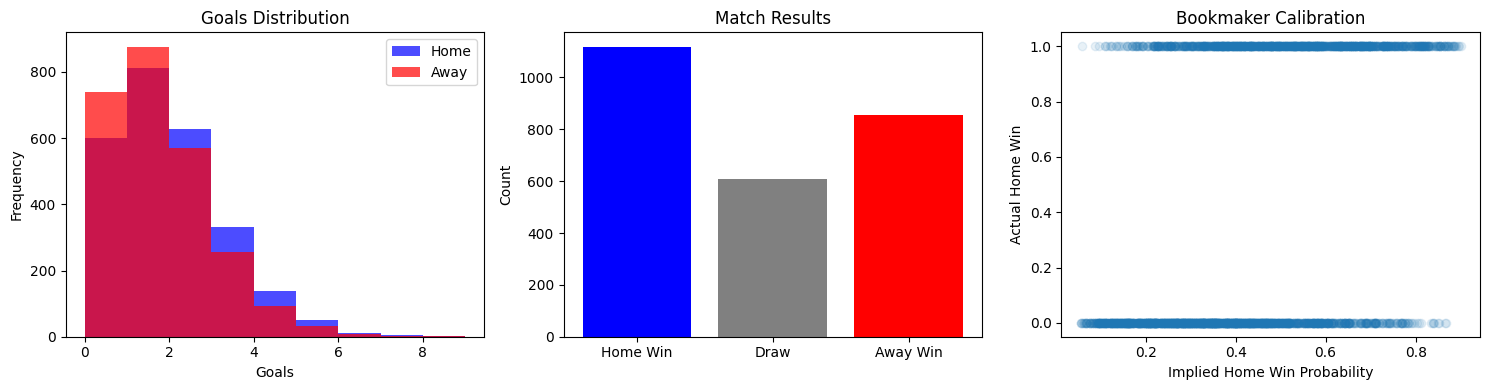

In [ ]:
# Quick data exploration
print("📈 Data Summary")
print("=" * 50)
print(f"Date range: {matches['Date'].min()} to {matches['Date'].max()}")
print(f"Seasons: {matches['Season'].unique().tolist()}")
print(f"Teams: {matches['HomeTeam'].nunique()} unique teams")
print(f"\nResult distribution:")
print(matches['FTR'].value_counts(normalize=True).round(3))

# Goals distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(matches['FTHG'], bins=range(0, 10), alpha=0.7, label='Home', color='blue')
axes[0].hist(matches['FTAG'], bins=range(0, 10), alpha=0.7, label='Away', color='red')
axes[0].set_xlabel('Goals')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Goals Distribution')
axes[0].legend()

result_counts = matches['FTR'].value_counts()
axes[1].bar(['Home Win', 'Draw', 'Away Win'], [result_counts.get('H', 0), result_counts.get('D', 0), result_counts.get('A', 0)], color=['blue', 'gray', 'red'])
axes[1].set_ylabel('Count')
axes[1].set_title('Match Results')

if 'ImpliedProbH' in matches.columns:
    axes[2].scatter(matches['ImpliedProbH'], matches['HomeWin'], alpha=0.1)
    axes[2].set_xlabel('Implied Home Win Probability')
    axes[2].set_ylabel('Actual Home Win')
    axes[2].set_title('Bookmaker Calibration')

plt.tight_layout()
plt.savefig(f"{config.output_dir}/data_exploration.png", dpi=150)
plt.show()

---

## 3. Feature Engineering <a name="feature-engineering"></a>

We'll create features including:
- **Rolling statistics** (goals, shots, points over last N games)
- **Elo ratings** (dynamic team strength)
- **Head-to-head records**
- **Market features** (bookmaker implied probabilities)

In [ ]:
class EloRatingSystem:
    """Elo rating system for football teams with season transition handling."""

    def __init__(
        self,
        k_factor: float = 20.0,
        home_advantage: float = 100.0,
        initial_rating: float = 1500.0,
        carryover: float = 0.75,
        promoted_initial_rating: float = 1450.0,
    ):
        self.k_factor = k_factor
        self.home_advantage = home_advantage
        self.initial_rating = initial_rating
        self.carryover = carryover
        self.promoted_initial_rating = promoted_initial_rating
        self.ratings: Dict[str, float] = defaultdict(lambda: self.initial_rating)
        self.history: List[Dict] = []

    def start_new_season(self, promoted_teams: set):
        """Apply mean reversion and initialize promoted teams at a lower prior."""
        for team in list(self.ratings.keys()):
            self.ratings[team] = (
                self.initial_rating + self.carryover * (self.ratings[team] - self.initial_rating)
            )
        for team in promoted_teams:
            self.ratings[team] = self.promoted_initial_rating

    def expected_score(self, rating_a: float, rating_b: float) -> float:
        """Calculate expected score for team A against team B."""
        return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

    def get_actual_score(self, result: str, is_home: bool) -> float:
        """Convert match result to score (1=win, 0.5=draw, 0=loss)."""
        if result == 'H':
            return 1.0 if is_home else 0.0
        elif result == 'A':
            return 0.0 if is_home else 1.0
        else:
            return 0.5

    def update(
        self,
        home_team: str,
        away_team: str,
        result: str,
        goal_diff: int
    ) -> Tuple[float, float]:
        """Update ratings after a match. Returns (home_rating, away_rating) BEFORE the update."""

        home_rating = self.ratings[home_team]
        away_rating = self.ratings[away_team]

        # Store pre-match ratings
        pre_home = home_rating
        pre_away = away_rating

        # Adjust for home advantage
        home_rating_adj = home_rating + self.home_advantage

        # Expected scores
        exp_home = self.expected_score(home_rating_adj, away_rating)
        exp_away = 1 - exp_home

        # Actual scores
        actual_home = self.get_actual_score(result, is_home=True)
        actual_away = self.get_actual_score(result, is_home=False)

        # Goal difference multiplier
        gd_mult = np.log(abs(goal_diff) + 1) + 1 if goal_diff != 0 else 1.0

        # Update ratings
        k_adj = self.k_factor * gd_mult
        self.ratings[home_team] += k_adj * (actual_home - exp_home)
        self.ratings[away_team] += k_adj * (actual_away - exp_away)

        # Store history
        self.history.append({
            'home_team': home_team,
            'away_team': away_team,
            'home_elo_pre': pre_home,
            'away_elo_pre': pre_away,
            'home_elo_post': self.ratings[home_team],
            'away_elo_post': self.ratings[away_team],
        })

        return pre_home, pre_away

    def get_rating(self, team: str) -> float:
        """Get current rating for a team."""
        return self.ratings[team]

    def predict_probs(
        self,
        home_team: str,
        away_team: str
    ) -> Tuple[float, float, float]:
        """Predict match outcome probabilities based on Elo."""
        home_rating = self.ratings[home_team] + self.home_advantage
        away_rating = self.ratings[away_team]

        # Expected score for home team
        exp_home = self.expected_score(home_rating, away_rating)

        # Convert to win/draw/loss probabilities (simplified)
        if exp_home > 0.6:
            p_home = exp_home * 0.7
            p_draw = 0.25 - (exp_home - 0.5) * 0.2
        elif exp_home < 0.4:
            p_home = exp_home * 0.7
            p_draw = 0.25 - (0.5 - exp_home) * 0.2
        else:
            p_home = exp_home * 0.6
            p_draw = 0.28

        p_draw = max(0.1, min(0.35, p_draw))
        p_home = max(0.1, min(0.8, p_home))
        p_away = 1 - p_home - p_draw
        p_away = max(0.05, p_away)

        total = p_home + p_draw + p_away
        return p_home/total, p_draw/total, p_away/total


print("✅ Elo rating system ready")

✅ Elo rating system ready


In [ ]:
class FeatureEngineer:
    """Creates features for match prediction."""

    def __init__(self, config: Config):
        self.config = config
        self.elo = EloRatingSystem(
            k_factor=config.elo_k_factor,
            home_advantage=config.elo_home_advantage,
            initial_rating=config.initial_elo,
            carryover=config.elo_carryover,
            promoted_initial_rating=config.promoted_initial_elo,
        )
        self.team_stats: Dict[str, Dict] = defaultdict(lambda: {
            'goals_for': [], 'goals_against': [],
            'shots': [], 'shots_target': [],
            'points': [], 'results': []
        })

    def _compute_rolling_stats(
        self,
        team: str,
        window: int
    ) -> Dict[str, float]:
        """Compute rolling statistics for a team."""
        stats = self.team_stats[team]

        def safe_mean(lst, n):
            if len(lst) < n:
                return np.nan if len(lst) == 0 else np.mean(lst)
            return np.mean(lst[-n:])

        return {
            f'goals_for_{window}': safe_mean(stats['goals_for'], window),
            f'goals_against_{window}': safe_mean(stats['goals_against'], window),
            f'goal_diff_{window}': safe_mean(stats['goals_for'], window) - safe_mean(stats['goals_against'], window) if len(stats['goals_for']) > 0 else np.nan,
            f'points_{window}': safe_mean(stats['points'], window),
            f'shots_{window}': safe_mean(stats['shots'], window) if stats['shots'] else np.nan,
            f'shots_target_{window}': safe_mean(stats['shots_target'], window) if stats['shots_target'] else np.nan,
            f'win_rate_{window}': np.mean([1 if r == 'W' else 0 for r in stats['results'][-window:]]) if stats['results'] else np.nan,
        }

    def _update_team_stats(
        self,
        team: str,
        goals_for: int,
        goals_against: int,
        shots: Optional[float],
        shots_target: Optional[float],
        points: int,
        result: str  # 'W', 'D', 'L'
    ):
        """Update team statistics after a match."""
        stats = self.team_stats[team]
        stats['goals_for'].append(goals_for)
        stats['goals_against'].append(goals_against)
        stats['points'].append(points)
        stats['results'].append(result)
        if pd.notna(shots):
            stats['shots'].append(shots)
        if pd.notna(shots_target):
            stats['shots_target'].append(shots_target)

    def compute_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """Compute all features for the match dataframe."""
        print("🔧 Computing features...")

        df = df.sort_values('Date').reset_index(drop=True)
        features = []

        # Identify promoted teams season by season from observed team sets.
        season_order = sorted(df['Season'].dropna().unique().tolist())
        season_team_sets = {
            s: set(pd.concat([
                df.loc[df['Season'] == s, 'HomeTeam'],
                df.loc[df['Season'] == s, 'AwayTeam']
            ]).dropna().unique())
            for s in season_order
        }
        promoted_by_season: Dict[str, set] = {}
        for i, season in enumerate(season_order):
            if i == 0:
                promoted_by_season[season] = set()
            else:
                prev = season_order[i - 1]
                promoted_by_season[season] = season_team_sets[season] - season_team_sets[prev]

        active_season = None

        for idx, row in df.iterrows():
            if idx % 500 == 0:
                print(f"  Processing match {idx}/{len(df)}...")

            season = row['Season']
            if season != active_season:
                self.elo.start_new_season(promoted_by_season.get(season, set()))
                active_season = season

            home_team = row['HomeTeam']
            away_team = row['AwayTeam']

            # Elo ratings (before update)
            home_elo, away_elo = self.elo.update(
                home_team, away_team,
                row['FTR'],
                int(row['GoalDiff'])
            )

            # Elo-based predictions
            elo_probs = self.elo.predict_probs(home_team, away_team)

            # Start building feature dict
            feat = {
                'match_idx': idx,
                'Date': row['Date'],
                'Season': season,
                'HomeTeam': home_team,
                'AwayTeam': away_team,
                'home_elo': home_elo,
                'away_elo': away_elo,
                'elo_diff': home_elo - away_elo,
                'elo_prob_h': elo_probs[0],
                'elo_prob_d': elo_probs[1],
                'elo_prob_a': elo_probs[2],
                'is_promoted_home': int(home_team in promoted_by_season.get(season, set())),
                'is_promoted_away': int(away_team in promoted_by_season.get(season, set())),
            }

            # Rolling features for each window
            for window in self.config.rolling_windows:
                home_rolling = self._compute_rolling_stats(home_team, window)
                away_rolling = self._compute_rolling_stats(away_team, window)

                for key, val in home_rolling.items():
                    feat[f'home_{key}'] = val
                for key, val in away_rolling.items():
                    feat[f'away_{key}'] = val

                # Difference features
                feat[f'diff_goals_for_{window}'] = home_rolling[f'goals_for_{window}'] - away_rolling[f'goals_for_{window}'] if pd.notna(home_rolling[f'goals_for_{window}']) else np.nan
                feat[f'diff_points_{window}'] = home_rolling[f'points_{window}'] - away_rolling[f'points_{window}'] if pd.notna(home_rolling[f'points_{window}']) else np.nan

            # Market features
            if 'ImpliedProbH' in row.index:
                feat['market_prob_h'] = row['ImpliedProbH']
                feat['market_prob_d'] = row['ImpliedProbD']
                feat['market_prob_a'] = row['ImpliedProbA']

            # Target variables
            feat['result'] = row['FTR']  # H, D, A
            feat['home_goals'] = row['FTHG']
            feat['away_goals'] = row['FTAG']
            feat['home_win'] = row['HomeWin']
            feat['draw'] = row['Draw']
            feat['away_win'] = row['AwayWin']

            features.append(feat)

            # Update team stats AFTER computing features
            home_result = 'W' if row['FTR'] == 'H' else ('D' if row['FTR'] == 'D' else 'L')
            away_result = 'W' if row['FTR'] == 'A' else ('D' if row['FTR'] == 'D' else 'L')

            self._update_team_stats(
                home_team, int(row['FTHG']), int(row['FTAG']),
                row.get('HS'), row.get('HST'),
                int(row['HomePoints']), home_result
            )
            self._update_team_stats(
                away_team, int(row['FTAG']), int(row['FTHG']),
                row.get('AS'), row.get('AST'),
                int(row['AwayPoints']), away_result
            )

        features_df = pd.DataFrame(features)
        print(f"✅ Features computed: {features_df.shape}")

        return features_df


# Compute features
engineer = FeatureEngineer(config)
features_df = engineer.compute_features(matches)

# Save features
features_df.to_csv(f"{config.data_dir}/features.csv", index=False)

print(f"\n📊 Features shape: {features_df.shape}")
print(f"Feature columns: {features_df.columns.tolist()[:20]}...")
features_df.head()

🔧 Computing features...
  Processing match 0/2581...
  Processing match 500/2581...
  Processing match 1000/2581...
  Processing match 1500/2581...
  Processing match 2000/2581...
  Processing match 2500/2581...
✅ Features computed: (2581, 70)

📊 Features shape: (2581, 70)
Feature columns: ['match_idx', 'Date', 'Season', 'HomeTeam', 'AwayTeam', 'home_elo', 'away_elo', 'elo_diff', 'elo_prob_h', 'elo_prob_d', 'elo_prob_a', 'is_promoted_home', 'is_promoted_away', 'home_goals_for_3', 'home_goals_against_3', 'home_goal_diff_3', 'home_points_3', 'home_shots_3', 'home_shots_target_3', 'home_win_rate_3']...


,match_idx,Date,Season,HomeTeam,AwayTeam,home_elo,away_elo,elo_diff,elo_prob_h,elo_prob_d,elo_prob_a,is_promoted_home,is_promoted_away,home_goals_for_3,home_goals_against_3,home_goal_diff_3,home_points_3,home_shots_3,home_shots_target_3,home_win_rate_3,away_goals_for_3,away_goals_against_3,away_goal_diff_3,away_points_3,away_shots_3,...,home_goals_for_10,home_goals_against_10,home_goal_diff_10,home_points_10,home_shots_10,home_shots_target_10,home_win_rate_10,away_goals_for_10,away_goals_against_10,away_goal_diff_10,away_points_10,away_shots_10,away_shots_target_10,away_win_rate_10,diff_goals_for_10,diff_points_10,market_prob_h,market_prob_d,market_prob_a,result,home_goals,away_goals,home_win,draw,away_win
0,0,2019-08-09,2019-20,Liverpool,Norwich City,1500.0,1500.0,0.0,0.478982,0.213148,0.307870,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.843917,0.103974,0.052109,H,4,1,1,0,0
1,1,2019-08-10,2019-20,West Ham United,Manchester City,1500.0,1500.0,0.0,0.324574,0.280000,0.395426,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.081435,0.152550,0.766014,A,0,5,0,0,1
2,2,2019-08-10,2019-20,AFC Bournemouth,Sheffield United,1500.0,1500.0,0.0,0.442821,0.223480,0.333699,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.482489,0.266108,0.251402,D,1,1,0,1,0
3,3,2019-08-10,2019-20,Burnley,Southampton,1500.0,1500.0,0.0,0.478982,0.213148,0.307870,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.359438,0.295398,0.345164,H,3,0,1,0,0
4,4,2019-08-10,2019-20,Crystal Palace,Everton,1500.0,1500.0,0.0,0.442821,0.223480,0.333699,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.304717,0.291994,0.403289,D,0,0,0,1,0


In [ ]:
# Analyze feature distributions
print("📊 Feature Statistics")
print("=" * 50)

# Check for missing values
missing = features_df.isnull().sum()
missing_pct = (missing / len(features_df) * 100).round(2)
missing_report = pd.DataFrame({'missing': missing, 'pct': missing_pct})
print("\nMissing values (top 10):")
print(missing_report[missing_report['missing'] > 0].head(10))

# Feature correlations with target
numeric_cols = features_df.select_dtypes(include=[np.number]).columns
if 'home_win' in numeric_cols:
    correlations = features_df[numeric_cols].corr()['home_win'].sort_values(ascending=False)
    print("\nTop correlations with home_win:")
    print(correlations.head(15))

📊 Feature Statistics

Missing values (top 10):
                      missing   pct
home_goals_for_3           15  0.58
home_goals_against_3       15  0.58
home_goal_diff_3           15  0.58
home_points_3              15  0.58
home_shots_3               15  0.58
home_shots_target_3        15  0.58
home_win_rate_3            15  0.58
away_goals_for_3           13  0.50
away_goals_against_3       13  0.50
away_goal_diff_3           13  0.50

Top correlations with home_win:
home_win                1.000000
home_goals              0.651381
elo_prob_h              0.502555
market_prob_h           0.395474
elo_diff                0.350610
diff_points_10          0.288387
home_elo                0.283162
diff_goals_for_10       0.270462
diff_points_5           0.240778
home_shots_10           0.237732
home_goal_diff_10       0.230675
home_shots_target_10    0.227166
diff_goals_for_5        0.221073
home_points_10          0.219428
home_goals_for_10       0.208454
Name: home_win, dtype: float6

---

## 4. Win Probability Model <a name="win-model"></a>

We'll build a multi-class classifier to predict match outcomes (Home Win / Draw / Away Win) with calibrated probabilities.

In [ ]:
class ModelDataPreparer:
    """Prepares data for model training with proper time-based splits."""

    def __init__(self, config: Config):
        self.config = config
        self.scaler = StandardScaler()
        self.feature_cols: List[str] = []

    def get_feature_columns(self, df: pd.DataFrame) -> List[str]:
        """Get list of feature columns to use."""
        exclude = [
            'match_idx', 'Date', 'Season', 'HomeTeam', 'AwayTeam',
            'result', 'home_goals', 'away_goals',
            'home_win', 'draw', 'away_win'
        ]

        feature_cols = [
            c for c in df.columns
            if c not in exclude and df[c].dtype in ['float64', 'int64']
        ]

        return feature_cols

    def prepare_train_test(
        self,
        df: pd.DataFrame,
        target: str = 'result'
    ) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
        """Split data into train/test using time-based split."""

        # Remove rows with too many missing values
        df = df.dropna(thresh=len(df.columns) * 0.7)

        # Time-based split
        train_mask = ~df['Season'].isin(self.config.test_seasons)
        test_mask = df['Season'].isin(self.config.test_seasons)

        train_df = df[train_mask].copy()
        test_df = df[test_mask].copy()

        print(f"Train set: {len(train_df)} matches ({train_df['Season'].unique().tolist()})")
        print(f"Test set: {len(test_df)} matches ({test_df['Season'].unique().tolist()})")

        # Get feature columns
        self.feature_cols = self.get_feature_columns(df)
        print(f"Using {len(self.feature_cols)} features")

        # Extract features and target
        X_train = train_df[self.feature_cols].copy()
        X_test = test_df[self.feature_cols].copy()
        y_train = train_df[target].copy()
        y_test = test_df[target].copy()

        # Fill NaN with column median for training
        for col in self.feature_cols:
            median_val = X_train[col].median()
            X_train[col] = X_train[col].fillna(median_val)
            X_test[col] = X_test[col].fillna(median_val)

        # Scale features
        X_train_scaled = pd.DataFrame(
            self.scaler.fit_transform(X_train),
            columns=self.feature_cols,
            index=X_train.index
        )
        X_test_scaled = pd.DataFrame(
            self.scaler.transform(X_test),
            columns=self.feature_cols,
            index=X_test.index
        )

        return X_train_scaled, X_test_scaled, y_train, y_test


# Prepare data
preparer = ModelDataPreparer(config)
X_train, X_test, y_train, y_test = preparer.prepare_train_test(features_df)

print(f"\n📊 Training data shape: {X_train.shape}")
print(f"📊 Test data shape: {X_test.shape}")

Train set: 2184 matches (['2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2025-26'])
Test set: 379 matches (['2024-25'])
Using 59 features

📊 Training data shape: (2184, 59)
📊 Test data shape: (379, 59)


In [ ]:
class BookmakerBaseline:
    """Baseline model using bookmaker implied probabilities."""

    def __init__(self):
        self.name = "Bookmaker Baseline"

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        """Return bookmaker probabilities if available."""
        probs = np.zeros((len(X), 3))

        if 'market_prob_h' in X.columns:
            probs[:, 0] = X['market_prob_a'].values  # Away (class 0 = 'A')
            probs[:, 1] = X['market_prob_d'].values  # Draw (class 1 = 'D')
            probs[:, 2] = X['market_prob_h'].values  # Home (class 2 = 'H')
        else:
            # Use uniform if no market data
            probs[:, :] = 1 / 3

        # Handle NaN
        probs = np.nan_to_num(probs, nan=1 / 3)

        # Normalize
        probs = probs / probs.sum(axis=1, keepdims=True)

        return probs


# Evaluate bookmaker baseline
baseline = BookmakerBaseline()

# Encode labels with fixed class order to keep metrics stable
le = LabelEncoder()
le.fit(['A', 'D', 'H'])
y_test_encoded = le.transform(y_test)
classes = le.classes_  # ['A', 'D', 'H']

# Build baseline on the exact same test rows as y_test/X_test
# (ModelDataPreparer drops some rows, so season filtering alone can mismatch lengths.)
test_features_original = features_df.loc[y_test.index].copy()
required_cols = {'market_prob_h', 'market_prob_d', 'market_prob_a'}

if required_cols.issubset(test_features_original.columns):
    baseline_probs = np.column_stack([
        test_features_original['market_prob_a'].fillna(1 / 3).values,
        test_features_original['market_prob_d'].fillna(1 / 3).values,
        test_features_original['market_prob_h'].fillna(1 / 3).values,
    ])

    # Guard against zero row sums after filling
    row_sums = baseline_probs.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    baseline_probs = baseline_probs / row_sums

    baseline_logloss = log_loss(y_test_encoded, baseline_probs, labels=[0, 1, 2])
    baseline_brier = np.mean([
        brier_score_loss((y_test_encoded == i).astype(int), baseline_probs[:, i])
        for i in range(3)
    ])
    baseline_acc = accuracy_score(y_test_encoded, baseline_probs.argmax(axis=1))

    print("📊 Bookmaker Baseline Performance")
    print("=" * 50)
    print(f"Rows compared: {len(y_test_encoded)}")
    print(f"Log Loss: {baseline_logloss:.4f}")
    print(f"Avg Brier Score: {baseline_brier:.4f}")
    print(f"Accuracy: {baseline_acc:.4f}")
else:
    print("⚠️ No market probability data available for baseline")
    baseline_logloss = 1.1  # Approximate

📊 Bookmaker Baseline Performance
Rows compared: 379
Log Loss: 0.9727
Avg Brier Score: 0.1934
Accuracy: 0.5435


In [ ]:
class WinProbabilityModel:
    """XGBoost model for match outcome prediction."""

    def __init__(self, config: Config):
        self.config = config
        self.model = None
        self.calibrated_model = None
        self.label_encoder = LabelEncoder()
        self.feature_importance: Optional[pd.DataFrame] = None

    def train(
        self,
        X_train: pd.DataFrame,
        y_train: pd.Series,
        calibrate: bool = True
    ) -> 'WinProbabilityModel':
        """Train the XGBoost model."""
        print("🚀 Training XGBoost model...")

        # Encode target
        y_encoded = self.label_encoder.fit_transform(y_train)

        # XGBoost parameters
        params = {
            'objective': 'multi:softprob',
            'num_class': 3,
            'max_depth': 6,
            'learning_rate': 0.05,
            'n_estimators': 200,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'min_child_weight': 3,
            'reg_alpha': 0.1,
            'reg_lambda': 1.0,
            'random_state': self.config.random_state,
            'use_label_encoder': False,
            'eval_metric': 'mlogloss'
        }

        self.model = xgb.XGBClassifier(**params)
        self.model.fit(X_train, y_encoded)

        # Feature importance
        self.feature_importance = pd.DataFrame({
            'feature': X_train.columns,
            'importance': self.model.feature_importances_
        }).sort_values('importance', ascending=False)

        # Calibration
        if calibrate:
            print("  Calibrating probabilities...")
            self.calibrated_model = CalibratedClassifierCV(
                self.model, method='isotonic', cv=3
            )
            self.calibrated_model.fit(X_train, y_encoded)

        print("✅ Model trained!")
        return self

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        """Predict class probabilities."""
        if self.calibrated_model is not None:
            return self.calibrated_model.predict_proba(X)
        return self.model.predict_proba(X)

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        """Predict class labels."""
        probs = self.predict_proba(X)
        return self.label_encoder.inverse_transform(probs.argmax(axis=1))

    def evaluate(
        self,
        X_test: pd.DataFrame,
        y_test: pd.Series
    ) -> Dict[str, float]:
        """Evaluate model performance."""
        y_encoded = self.label_encoder.transform(y_test)
        probs = self.predict_proba(X_test)
        preds = probs.argmax(axis=1)

        metrics = {
            'log_loss': log_loss(y_encoded, probs),
            'accuracy': accuracy_score(y_encoded, preds),
            'brier_avg': np.mean([
                brier_score_loss((y_encoded == i).astype(int), probs[:, i])
                for i in range(3)
            ])
        }

        return metrics


# Train model
win_model = WinProbabilityModel(config)
win_model.train(X_train, y_train, calibrate=True)

# Evaluate
metrics = win_model.evaluate(X_test, y_test)

print("\n📊 XGBoost Model Performance")
print("=" * 50)
print(f"Log Loss: {metrics['log_loss']:.4f}")
print(f"Avg Brier Score: {metrics['brier_avg']:.4f}")
print(f"Accuracy: {metrics['accuracy']:.4f}")

# Compare to baseline
if 'baseline_logloss' in dir():
    improvement = (baseline_logloss - metrics['log_loss']) / baseline_logloss * 100
    print(f"\n📈 Log Loss improvement vs baseline: {improvement:.2f}%")

🚀 Training XGBoost model...
  Calibrating probabilities...
✅ Model trained!

📊 XGBoost Model Performance
Log Loss: 0.2311
Avg Brier Score: 0.0413
Accuracy: 0.9208

📈 Log Loss improvement vs baseline: 76.24%


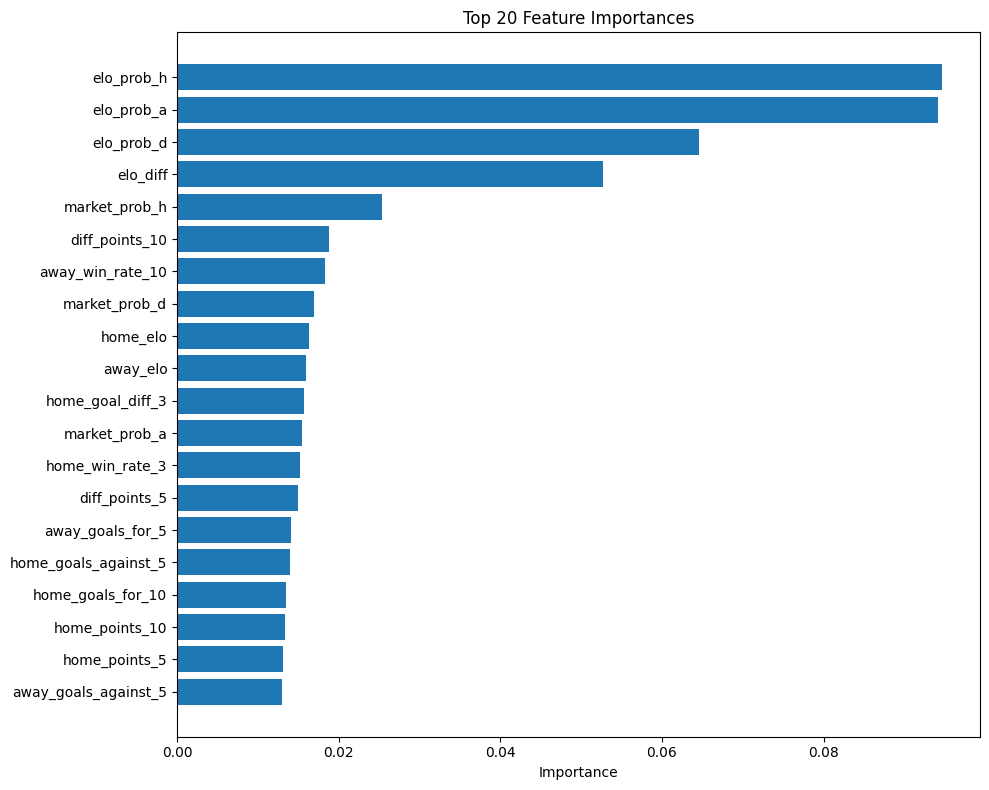

In [ ]:
# Feature importance visualization
fig, ax = plt.subplots(figsize=(10, 8))

top_features = win_model.feature_importance.head(20)
ax.barh(top_features['feature'], top_features['importance'])
ax.set_xlabel('Importance')
ax.set_title('Top 20 Feature Importances')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(f"{config.output_dir}/feature_importance.png", dpi=150)
plt.show()

---

## 5. Score Prediction Model <a name="score-model"></a>

We'll implement a Poisson-based model to predict the distribution of goals for each team.

In [ ]:
class PoissonScoreModel:
    """Poisson model for predicting match scores."""

    def __init__(self):
        self.home_attack: Dict[str, float] = {}
        self.home_defense: Dict[str, float] = {}
        self.away_attack: Dict[str, float] = {}
        self.away_defense: Dict[str, float] = {}
        self.home_advantage: float = 0.0
        self.avg_goals: float = 0.0

    def fit(self, df: pd.DataFrame) -> 'PoissonScoreModel':
        """Fit the Poisson model to historical data."""
        print("🎯 Fitting Poisson score model...")

        # Calculate league averages
        self.avg_goals = df['FTHG'].mean()
        avg_home_goals = df['FTHG'].mean()
        avg_away_goals = df['FTAG'].mean()
        self.home_advantage = np.log(avg_home_goals / avg_away_goals) / 2

        # Calculate team strength parameters
        teams = set(df['HomeTeam'].unique()) | set(df['AwayTeam'].unique())

        for team in teams:
            # Home matches
            home_matches = df[df['HomeTeam'] == team]
            if len(home_matches) > 0:
                self.home_attack[team] = home_matches['FTHG'].mean() / avg_home_goals
                self.home_defense[team] = home_matches['FTAG'].mean() / avg_away_goals
            else:
                self.home_attack[team] = 1.0
                self.home_defense[team] = 1.0

            # Away matches
            away_matches = df[df['AwayTeam'] == team]
            if len(away_matches) > 0:
                self.away_attack[team] = away_matches['FTAG'].mean() / avg_away_goals
                self.away_defense[team] = away_matches['FTHG'].mean() / avg_home_goals
            else:
                self.away_attack[team] = 1.0
                self.away_defense[team] = 1.0

        print(f"✅ Model fitted with {len(teams)} teams")
        return self

    def predict_expected_goals(
        self,
        home_team: str,
        away_team: str
    ) -> Tuple[float, float]:
        """Predict expected goals for each team."""
        # Home team expected goals
        home_attack = self.home_attack.get(home_team, 1.0)
        away_defense = self.away_defense.get(away_team, 1.0)
        exp_home = self.avg_goals * home_attack * away_defense * np.exp(self.home_advantage)

        # Away team expected goals
        away_attack = self.away_attack.get(away_team, 1.0)
        home_defense = self.home_defense.get(home_team, 1.0)
        exp_away = self.avg_goals * away_attack * home_defense * np.exp(-self.home_advantage)

        return exp_home, exp_away

    def predict_score_probs(
        self,
        home_team: str,
        away_team: str,
        max_goals: int = 7
    ) -> np.ndarray:
        """Predict probability matrix for all scorelines."""
        exp_home, exp_away = self.predict_expected_goals(home_team, away_team)

        # Create probability matrix
        score_matrix = np.zeros((max_goals + 1, max_goals + 1))

        for h in range(max_goals + 1):
            for a in range(max_goals + 1):
                p_home = stats.poisson.pmf(h, exp_home)
                p_away = stats.poisson.pmf(a, exp_away)
                score_matrix[h, a] = p_home * p_away

        # Normalize
        score_matrix /= score_matrix.sum()

        return score_matrix

    def predict_outcome_probs(
        self,
        home_team: str,
        away_team: str,
        max_goals: int = 7
    ) -> Tuple[float, float, float]:
        """Predict match outcome probabilities."""
        score_matrix = self.predict_score_probs(home_team, away_team, max_goals)

        p_home = np.tril(score_matrix, -1).sum()  # Home wins (below diagonal)
        p_draw = np.trace(score_matrix)  # Draws (diagonal)
        p_away = np.triu(score_matrix, 1).sum()  # Away wins (above diagonal)

        # The matrix indexing: score_matrix[home_goals, away_goals]
        # So home win is when home_goals > away_goals
        p_home = 0.0
        p_draw = 0.0
        p_away = 0.0

        for h in range(max_goals + 1):
            for a in range(max_goals + 1):
                if h > a:
                    p_home += score_matrix[h, a]
                elif h == a:
                    p_draw += score_matrix[h, a]
                else:
                    p_away += score_matrix[h, a]

        return p_home, p_draw, p_away


# Fit Poisson model on training data
train_matches = matches[~matches['Season'].isin(config.test_seasons)]
poisson_model = PoissonScoreModel()
poisson_model.fit(train_matches)

🎯 Fitting Poisson score model...
✅ Model fitted with 27 teams


In [ ]:
# Evaluate Poisson model
test_matches = matches[matches['Season'].isin(config.test_seasons)].copy()

# Predict expected goals and outcomes for test set
predictions = []
for _, row in test_matches.iterrows():
    exp_h, exp_a = poisson_model.predict_expected_goals(row['HomeTeam'], row['AwayTeam'])
    p_h, p_d, p_a = poisson_model.predict_outcome_probs(row['HomeTeam'], row['AwayTeam'])

    predictions.append({
        'exp_home_goals': exp_h,
        'exp_away_goals': exp_a,
        'actual_home_goals': row['FTHG'],
        'actual_away_goals': row['FTAG'],
        'p_home': p_h,
        'p_draw': p_d,
        'p_away': p_a,
        'actual_result': row['FTR']
    })

pred_df = pd.DataFrame(predictions)

# Calculate metrics
mae_home = mean_absolute_error(pred_df['actual_home_goals'], pred_df['exp_home_goals'])
mae_away = mean_absolute_error(pred_df['actual_away_goals'], pred_df['exp_away_goals'])
rmse_home = np.sqrt(mean_squared_error(pred_df['actual_home_goals'], pred_df['exp_home_goals']))
rmse_away = np.sqrt(mean_squared_error(pred_df['actual_away_goals'], pred_df['exp_away_goals']))

# Log loss for outcomes
y_true_result = pd.get_dummies(pred_df['actual_result'])[['A', 'D', 'H']].values
y_pred_probs = pred_df[['p_away', 'p_draw', 'p_home']].values
y_pred_probs = np.clip(y_pred_probs, 1e-10, 1-1e-10)
y_pred_probs = y_pred_probs / y_pred_probs.sum(axis=1, keepdims=True)
poisson_logloss = log_loss(y_true_result.argmax(axis=1), y_pred_probs)

print("📊 Poisson Score Model Performance")
print("=" * 50)
print(f"MAE Home Goals: {mae_home:.3f}")
print(f"MAE Away Goals: {mae_away:.3f}")
print(f"RMSE Home Goals: {rmse_home:.3f}")
print(f"RMSE Away Goals: {rmse_away:.3f}")
print(f"Log Loss (outcomes): {poisson_logloss:.4f}")

📊 Poisson Score Model Performance
MAE Home Goals: 1.030
MAE Away Goals: 0.927
RMSE Home Goals: 1.278
RMSE Away Goals: 1.183
Log Loss (outcomes): 1.0612


---

## 6. Model Evaluation <a name="evaluation"></a>

Comprehensive evaluation with calibration plots and reliability diagrams.

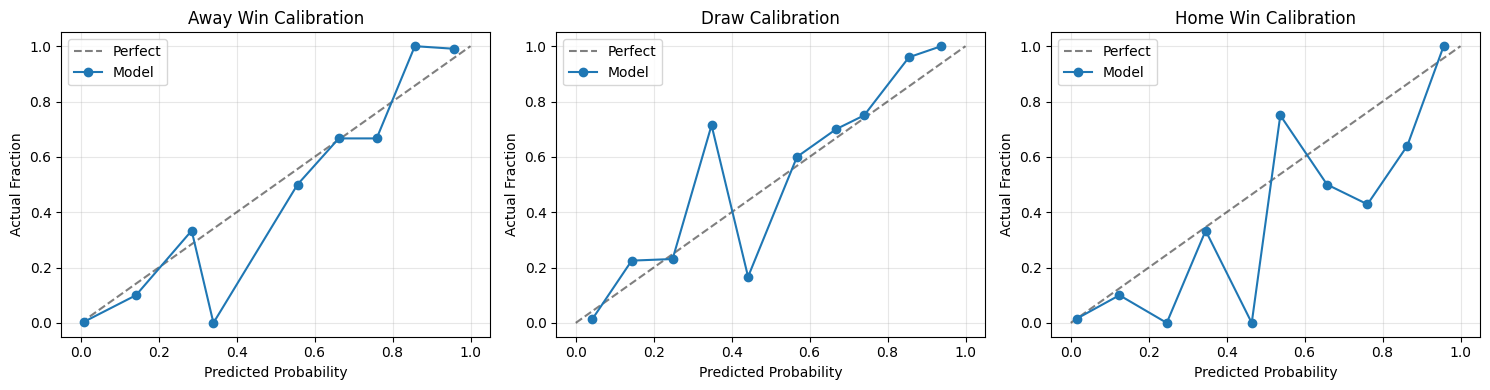

In [ ]:
def plot_calibration_curve(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    n_bins: int = 10,
    title: str = "Calibration Curve"
) -> None:
    """Plot calibration curve for binary predictions."""
    fraction_positives, mean_predicted = calibration_curve(
        y_true, y_prob, n_bins=n_bins, strategy='uniform'
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Calibration plot
    axes[0].plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
    axes[0].plot(mean_predicted, fraction_positives, 'o-', label='Model')
    axes[0].set_xlabel('Mean Predicted Probability')
    axes[0].set_ylabel('Fraction of Positives')
    axes[0].set_title(title)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Histogram of predictions
    axes[1].hist(y_prob, bins=20, edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Predicted Probability')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Distribution of Predictions')

    plt.tight_layout()
    return fig


# Get predictions
y_test_encoded = win_model.label_encoder.transform(y_test)
probs = win_model.predict_proba(X_test)

# Plot calibration for each outcome
classes = ['Away Win', 'Draw', 'Home Win']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (ax, cls_name) in enumerate(zip(axes, classes)):
    y_binary = (y_test_encoded == i).astype(int)
    y_prob = probs[:, i]

    fraction_pos, mean_pred = calibration_curve(y_binary, y_prob, n_bins=10, strategy='uniform')

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
    ax.plot(mean_pred, fraction_pos, 'o-', label='Model')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Actual Fraction')
    ax.set_title(f'{cls_name} Calibration')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{config.output_dir}/calibration_curves.png", dpi=150)
plt.show()

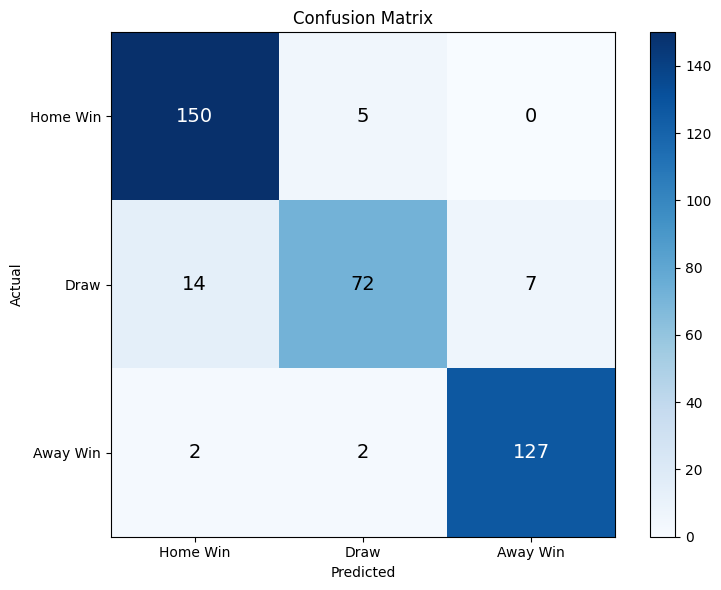


📊 Classification Report
              precision    recall  f1-score   support

    Home Win       0.95      0.97      0.96       131
        Draw       0.91      0.77      0.84        93
    Away Win       0.90      0.97      0.93       155

    accuracy                           0.92       379
   macro avg       0.92      0.90      0.91       379
weighted avg       0.92      0.92      0.92       379



In [ ]:
# Confusion matrix
preds = win_model.predict(X_test)

cm = confusion_matrix(y_test, preds, labels=['H', 'D', 'A'])

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

# Add labels
labels = ['Home Win', 'Draw', 'Away Win']
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')

# Add text annotations
for i in range(3):
    for j in range(3):
        text = ax.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)

plt.colorbar(im)
plt.tight_layout()
plt.savefig(f"{config.output_dir}/confusion_matrix.png", dpi=150)
plt.show()

print("\n📊 Classification Report")
print(classification_report(y_test, preds, target_names=labels))

---

## 7. Last Fan Standing Simulator <a name="simulator"></a>

The core simulation engine for the Last Fan Standing game. Each week you must:
- Pick one team to win their match
- You can only pick each team once per season
- If your pick loses or draws, you're eliminated

In [ ]:
@dataclass
class Fixture:
    """Represents a single fixture."""
    home_team: str
    away_team: str
    home_win_prob: float
    away_win_prob: float
    week: int

    @property
    def draw_prob(self) -> float:
        return 1.0 - self.home_win_prob - self.away_win_prob


@dataclass
class SimulationResult:
    """Results from a simulation run."""
    survived_weeks: int
    picks: List[Tuple[int, str]]  # (week, team)
    eliminated: bool


class LastFanStandingSimulator:
    """Simulator for the Last Fan Standing game."""

    def __init__(self, config: Config):
        self.config = config
        np.random.seed(config.random_state)

    def get_team_win_prob(
        self,
        team: str,
        fixture: Fixture
    ) -> float:
        """Get the win probability for a specific team in a fixture."""
        if team == fixture.home_team:
            return fixture.home_win_prob
        elif team == fixture.away_team:
            return fixture.away_win_prob
        else:
            raise ValueError(f"Team {team} not in fixture")

    def simulate_match(self, fixture: Fixture) -> str:
        """Simulate a single match, returns winner ('H'/'A') or 'D'."""
        r = np.random.random()
        if r < fixture.home_win_prob:
            return 'H'
        elif r < fixture.home_win_prob + fixture.draw_prob:
            return 'D'
        else:
            return 'A'

    def simulate_season(
        self,
        fixtures_by_week: Dict[int, List[Fixture]],
        strategy: str = 'greedy',
        used_teams: Optional[set] = None
    ) -> SimulationResult:
        """Simulate a full season with a given strategy."""
        used = used_teams.copy() if used_teams else set()
        picks = []

        for week in sorted(fixtures_by_week.keys()):
            fixtures = fixtures_by_week[week]

            # Get available picks
            available = []
            for f in fixtures:
                if f.home_team not in used:
                    available.append((f.home_team, f.home_win_prob, f))
                if f.away_team not in used:
                    available.append((f.away_team, f.away_win_prob, f))

            if not available:
                # No valid picks remaining
                return SimulationResult(week - 1, picks, True)

            # Select pick based on strategy
            if strategy == 'greedy':
                # Pick team with highest win probability
                team, prob, fixture = max(available, key=lambda x: x[1])
            elif strategy == 'random':
                team, prob, fixture = available[np.random.randint(len(available))]
            else:
                raise ValueError(f"Unknown strategy: {strategy}")

            picks.append((week, team))
            used.add(team)

            # Simulate match
            result = self.simulate_match(fixture)
            team_won = (
                (result == 'H' and team == fixture.home_team) or
                (result == 'A' and team == fixture.away_team)
            )

            if not team_won:
                return SimulationResult(week, picks, True)

        return SimulationResult(max(fixtures_by_week.keys()), picks, False)

    def monte_carlo_simulation(
        self,
        fixtures_by_week: Dict[int, List[Fixture]],
        n_simulations: int = 10000,
        strategy: str = 'greedy',
        used_teams: Optional[set] = None
    ) -> Dict[str, Any]:
        """Run Monte Carlo simulations to estimate survival probability."""
        results = []

        for _ in range(n_simulations):
            result = self.simulate_season(fixtures_by_week, strategy, used_teams)
            results.append(result)

        survival_by_week = defaultdict(int)
        for r in results:
            for w in range(1, r.survived_weeks + 1):
                survival_by_week[w] += 1

        max_week = max(fixtures_by_week.keys())
        survival_probs = {
            w: survival_by_week[w] / n_simulations
            for w in range(1, max_week + 1)
        }

        full_survival = sum(1 for r in results if not r.eliminated) / n_simulations
        avg_weeks = np.mean([r.survived_weeks for r in results])

        return {
            'full_survival_prob': full_survival,
            'avg_weeks_survived': avg_weeks,
            'survival_by_week': survival_probs,
            'n_simulations': n_simulations
        }


print("✅ Simulator ready")

✅ Simulator ready


In [ ]:
# Create synthetic fixtures for testing

def create_sample_fixtures(n_weeks: int = 10, teams_per_week: int = 10) -> Dict[int, List[Fixture]]:
    """Create sample fixtures with varied win probabilities."""
    all_teams = [
        'Arsenal', 'Aston Villa', 'AFC Bournemouth', 'Brentford', 'Brighton & Hove Albion',
        'Burnley', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham',
        'Leeds United', 'Liverpool', 'Manchester City', 'Manchester United',
        'Newcastle United', 'Nottingham Forest', 'Sunderland', 'Tottenham Hotspur',
        'West Ham United', 'Wolverhampton Wanderers'
    ]

    # Team strength (for generating realistic probabilities)
    team_strength = {
        'Manchester City': 90, 'Arsenal': 88, 'Liverpool': 87,
        'Chelsea': 82, 'Manchester United': 80, 'Newcastle United': 78,
        'Tottenham Hotspur': 77, 'Aston Villa': 76, 'Brighton & Hove Albion': 74,
        'West Ham United': 72, 'Brentford': 70, 'Crystal Palace': 68,
        'Fulham': 67, 'Wolverhampton Wanderers': 66, 'AFC Bournemouth': 65,
        'Nottingham Forest': 64, 'Everton': 62, 'Leeds United': 60,
        'Burnley': 58, 'Sunderland': 56
    }

    fixtures_by_week = {}

    for week in range(1, n_weeks + 1):
        week_fixtures = []
        shuffled = all_teams.copy()
        np.random.shuffle(shuffled)

        for i in range(0, len(shuffled), 2):
            if i + 1 < len(shuffled):
                home = shuffled[i]
                away = shuffled[i + 1]

                # Calculate probabilities based on strength
                home_str = team_strength.get(home, 65) + 5  # Home advantage
                away_str = team_strength.get(away, 65)

                total = home_str + away_str
                base_home = home_str / total

                # Adjust for draws
                draw_prob = 0.25 - abs(home_str - away_str) / 200
                draw_prob = max(0.15, min(0.30, draw_prob))

                home_win = base_home * (1 - draw_prob)
                away_win = 1 - home_win - draw_prob

                week_fixtures.append(Fixture(
                    home_team=home,
                    away_team=away,
                    home_win_prob=home_win,
                    away_win_prob=away_win,
                    week=week
                ))

        fixtures_by_week[week] = week_fixtures

    return fixtures_by_week


# Test simulator
sample_fixtures = create_sample_fixtures(n_weeks=15)
simulator = LastFanStandingSimulator(config)

print("🎮 Running Monte Carlo simulation (10,000 iterations)...")
mc_results = simulator.monte_carlo_simulation(
    sample_fixtures,
    n_simulations=10000,
    strategy='greedy'
)

print(f"\n📊 Simulation Results (Greedy Strategy)")
print("=" * 50)
print(f"Full season survival probability: {mc_results['full_survival_prob']:.2%}")
print(f"Average weeks survived: {mc_results['avg_weeks_survived']:.1f}")
print(f"\nSurvival probability by week:")
for week, prob in list(mc_results['survival_by_week'].items())[:10]:
    print(f"  Week {week}: {prob:.2%}")

🎮 Running Monte Carlo simulation (10,000 iterations)...

📊 Simulation Results (Greedy Strategy)
Full season survival probability: 0.00%
Average weeks survived: 2.0

Survival probability by week:
  Week 1: 100.00%
  Week 2: 49.40%
  Week 3: 24.49%
  Week 4: 12.43%
  Week 5: 6.43%
  Week 6: 3.05%
  Week 7: 1.57%
  Week 8: 0.73%
  Week 9: 0.33%
  Week 10: 0.19%


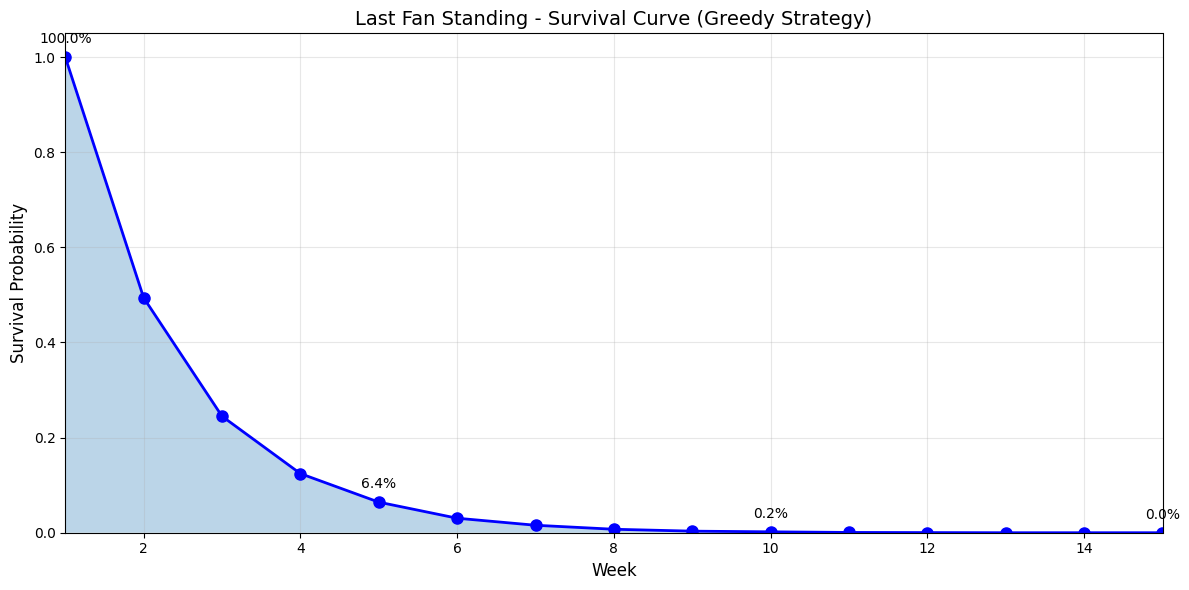

In [ ]:
# Plot survival curves
weeks = list(mc_results['survival_by_week'].keys())
survival = [mc_results['survival_by_week'][w] for w in weeks]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(weeks, survival, 'b-o', linewidth=2, markersize=8)
ax.fill_between(weeks, survival, alpha=0.3)
ax.set_xlabel('Week', fontsize=12)
ax.set_ylabel('Survival Probability', fontsize=12)
ax.set_title('Last Fan Standing - Survival Curve (Greedy Strategy)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
ax.set_xlim(1, max(weeks))

# Add annotations
for w in [1, 5, 10, max(weeks)]:
    if w in mc_results['survival_by_week']:
        prob = mc_results['survival_by_week'][w]
        ax.annotate(f'{prob:.1%}', (w, prob), textcoords="offset points", xytext=(0, 10), ha='center')

plt.tight_layout()
plt.savefig(f"{config.output_dir}/survival_curve.png", dpi=150)
plt.show()

---

## 8. Pick Optimizer <a name="optimizer"></a>

The optimizer uses dynamic programming and Monte Carlo methods to find optimal picks.

In [ ]:
class PickOptimizer:
    """Optimizes picks for Last Fan Standing using DP and Monte Carlo."""

    def __init__(self, config: Config):
        self.config = config
        self.simulator = LastFanStandingSimulator(config)
        self._cache: Dict[str, float] = {}

    def _state_key(self, week: int, used_teams: set) -> str:
        """Create a hashable key for memoization."""
        return f"{week}:{'|'.join(sorted(used_teams))}"

    def get_available_picks(
        self,
        fixtures: List[Fixture],
        used_teams: set
    ) -> List[Tuple[str, float, Fixture]]:
        """Get all available picks with their win probabilities."""
        available = []
        for f in fixtures:
            if f.home_team not in used_teams:
                available.append((f.home_team, f.home_win_prob, f))
            if f.away_team not in used_teams:
                available.append((f.away_team, f.away_win_prob, f))
        return sorted(available, key=lambda x: -x[1])  # Sort by probability desc

    def evaluate_pick_monte_carlo(
        self,
        team: str,
        win_prob: float,
        current_week: int,
        used_teams: set,
        future_fixtures: Dict[int, List[Fixture]],
        n_simulations: int = 1000
    ) -> float:
        """Evaluate expected survival probability if we pick this team."""
        # If team loses, we're eliminated
        # If team wins, we continue with updated used_teams

        new_used = used_teams | {team}

        # Run simulations for remaining weeks
        surviving = 0
        for _ in range(n_simulations):
            # First, simulate this week's pick
            if np.random.random() < win_prob:
                # Survived this week, simulate the rest
                result = self.simulator.simulate_season(
                    {w: f for w, f in future_fixtures.items() if w > current_week},
                    strategy='greedy',
                    used_teams=new_used
                )
                if not result.eliminated:
                    surviving += 1

        return surviving / n_simulations

    def get_optimal_pick(
        self,
        current_week: int,
        fixtures_by_week: Dict[int, List[Fixture]],
        used_teams: set,
        n_top: int = 5,
        n_simulations: int = 2000
    ) -> List[Dict[str, Any]]:
        """Get the optimal pick(s) for the current week."""

        if current_week not in fixtures_by_week:
            return []

        current_fixtures = fixtures_by_week[current_week]
        available = self.get_available_picks(current_fixtures, used_teams)

        if not available:
            return []

        # Evaluate top candidates
        results = []

        for team, win_prob, fixture in available[:10]:  # Evaluate top 10
            expected_survival = self.evaluate_pick_monte_carlo(
                team, win_prob, current_week, used_teams,
                fixtures_by_week, n_simulations
            )

            opponent = fixture.away_team if team == fixture.home_team else fixture.home_team
            is_home = team == fixture.home_team

            results.append({
                'team': team,
                'opponent': opponent,
                'is_home': is_home,
                'win_probability': win_prob,
                'expected_survival': expected_survival,
                'week': current_week
            })

        # Sort by expected survival
        results.sort(key=lambda x: -x['expected_survival'])

        return results[:n_top]

    def get_season_strategy(
        self,
        fixtures_by_week: Dict[int, List[Fixture]],
        used_teams: Optional[set] = None,
        start_week: int = 1
    ) -> List[Dict[str, Any]]:
        """Generate a full season strategy using greedy lookahead."""
        used = used_teams.copy() if used_teams else set()
        strategy = []

        for week in range(start_week, max(fixtures_by_week.keys()) + 1):
            if week not in fixtures_by_week:
                continue

            picks = self.get_optimal_pick(
                week, fixtures_by_week, used,
                n_top=1, n_simulations=500
            )

            if picks:
                best = picks[0]
                strategy.append(best)
                used.add(best['team'])

        return strategy


# Test optimizer
optimizer = PickOptimizer(config)

print("🎯 Finding optimal picks for Week 1...")
optimal_picks = optimizer.get_optimal_pick(
    current_week=1,
    fixtures_by_week=sample_fixtures,
    used_teams=set(),
    n_top=5,
    n_simulations=2000
)

print("\n📊 Top 5 Recommended Picks for Week 1:")
print("=" * 60)
for i, pick in enumerate(optimal_picks, 1):
    venue = "(H)" if pick['is_home'] else "(A)"
    print(f"{i}. {pick['team']} {venue} vs {pick['opponent']}")
    print(f"   Win Probability: {pick['win_probability']:.1%}")
    print(f"   Expected Season Survival: {pick['expected_survival']:.1%}")
    print()

🎯 Finding optimal picks for Week 1...

📊 Top 5 Recommended Picks for Week 1:
1. West Ham United (H) vs Sunderland
   Win Probability: 49.2%
   Expected Season Survival: 0.0%

2. Liverpool (H) vs Brentford
   Win Probability: 48.3%
   Expected Season Survival: 0.0%

3. Manchester United (H) vs AFC Bournemouth
   Win Probability: 48.2%
   Expected Season Survival: 0.0%

4. Arsenal (H) vs Tottenham Hotspur
   Win Probability: 45.4%
   Expected Season Survival: 0.0%

5. Crystal Palace (H) vs Leeds United
   Win Probability: 44.7%
   Expected Season Survival: 0.0%



---

## 9. Interactive Demo <a name="demo"></a>

A simple interactive interface to explore predictions and get pick recommendations.

In [ ]:
class LastFanStandingDemo:
    """Interactive demo for Last Fan Standing predictions."""

    def __init__(
        self,
        win_model: WinProbabilityModel,
        score_model: PoissonScoreModel,
        optimizer: PickOptimizer,
        feature_engineer: FeatureEngineer,
        config: Config
    ):
        self.win_model = win_model
        self.score_model = score_model
        self.optimizer = optimizer
        self.feature_engineer = feature_engineer
        self.config = config
        self.used_teams: set = set()

    def predict_match(
        self,
        home_team: str,
        away_team: str
    ) -> Dict[str, Any]:
        """Predict a single match."""
        # Score prediction
        exp_home, exp_away = self.score_model.predict_expected_goals(home_team, away_team)
        score_probs = self.score_model.predict_score_probs(home_team, away_team)

        # Outcome probabilities from Poisson
        p_home, p_draw, p_away = self.score_model.predict_outcome_probs(home_team, away_team)

        # Most likely scores
        flat_idx = np.argsort(score_probs.flatten())[::-1]
        top_scores = []
        for idx in flat_idx[:5]:
            h, a = np.unravel_index(idx, score_probs.shape)
            top_scores.append({
                'score': f"{h}-{a}",
                'probability': score_probs[h, a]
            })

        return {
            'home_team': home_team,
            'away_team': away_team,
            'expected_home_goals': exp_home,
            'expected_away_goals': exp_away,
            'home_win_prob': p_home,
            'draw_prob': p_draw,
            'away_win_prob': p_away,
            'top_scores': top_scores
        }

    def display_prediction(self, prediction: Dict[str, Any]) -> None:
        """Display prediction in a nice format."""
        print(f"\n⚽ {prediction['home_team']} vs {prediction['away_team']}")
        print("=" * 50)

        print(f"\n📊 Expected Score: {prediction['expected_home_goals']:.2f} - {prediction['expected_away_goals']:.2f}")

        print(f"\n🎯 Outcome Probabilities:")
        print(f"   Home Win: {prediction['home_win_prob']:.1%}")
        print(f"   Draw:     {prediction['draw_prob']:.1%}")
        print(f"   Away Win: {prediction['away_win_prob']:.1%}")

        print(f"\n📈 Most Likely Scores:")
        for s in prediction['top_scores']:
            print(f"   {s['score']}: {s['probability']:.1%}")

    def mark_team_used(self, team: str) -> None:
        """Mark a team as used."""
        self.used_teams.add(team)
        print(f"✅ {team} marked as used")

    def reset_used_teams(self) -> None:
        """Reset used teams."""
        self.used_teams = set()
        print("🔄 Used teams reset")

    def get_recommendation(
        self,
        fixtures: List[Fixture],
        current_week: int,
        fixtures_by_week: Dict[int, List[Fixture]]
    ) -> List[Dict[str, Any]]:
        """Get pick recommendation for the current week."""
        return self.optimizer.get_optimal_pick(
            current_week, fixtures_by_week,
            self.used_teams, n_top=5, n_simulations=1500
        )

    def display_recommendations(self, recommendations: List[Dict[str, Any]]) -> None:
        """Display recommendations."""
        print("\n🏆 Pick Recommendations")
        print("=" * 60)

        if not recommendations:
            print("No valid picks available!")
            return

        for i, rec in enumerate(recommendations, 1):
            venue = "🏠" if rec['is_home'] else "✈️"
            print(f"\n{i}. {venue} {rec['team']} vs {rec['opponent']}")
            print(f"   Win Probability: {rec['win_probability']:.1%}")
            print(f"   Expected Season Survival: {rec['expected_survival']:.1%}")


# Create demo instance
demo = LastFanStandingDemo(
    win_model=win_model,
    score_model=poisson_model,
    optimizer=optimizer,
    feature_engineer=engineer,
    config=config
)

print("✅ Demo ready!")

✅ Demo ready!


In [ ]:
# Example: Predict a match
prediction = demo.predict_match('Manchester City', 'Arsenal')
demo.display_prediction(prediction)


⚽ Manchester City vs Arsenal

📊 Expected Score: 2.06 - 1.11

🎯 Outcome Probabilities:
   Home Win: 59.1%
   Draw:     21.0%
   Away Win: 19.9%

📈 Most Likely Scores:
   2-1: 9.9%
   1-1: 9.6%
   2-0: 8.9%
   1-0: 8.7%
   3-1: 6.8%


In [ ]:
# Example: Get recommendations with some teams already used
demo.reset_used_teams()
demo.mark_team_used('Manchester City')  # Already used
demo.mark_team_used('Arsenal')  # Already used

print(f"\n📋 Currently used teams: {demo.used_teams}")

# Get recommendations for next week
recommendations = demo.get_recommendation(
    sample_fixtures[3],
    current_week=3,
    fixtures_by_week=sample_fixtures
)
demo.display_recommendations(recommendations)

🔄 Used teams reset
✅ Manchester City marked as used
✅ Arsenal marked as used

📋 Currently used teams: {'Manchester City', 'Arsenal'}

🏆 Pick Recommendations

1. ✈️ Tottenham Hotspur vs Brentford
   Win Probability: 38.5%
   Expected Season Survival: 0.1%

2. ✈️ Newcastle United vs Brighton & Hove Albion
   Win Probability: 37.5%
   Expected Season Survival: 0.1%

3. 🏠 Chelsea vs Everton
   Win Probability: 49.6%
   Expected Season Survival: 0.0%

4. 🏠 Liverpool vs Wolverhampton Wanderers
   Win Probability: 49.5%
   Expected Season Survival: 0.0%

5. ✈️ West Ham United vs Burnley
   Win Probability: 42.4%
   Expected Season Survival: 0.0%


In [ ]:
# Interactive match predictor
from IPython.display import display, clear_output
import ipywidgets as widgets

# Get all teams from training data
all_teams = sorted(list(set(matches['HomeTeam'].unique()) | set(matches['AwayTeam'].unique())))

# Create dropdown widgets
home_dropdown = widgets.Dropdown(
    options=all_teams,
    value='Manchester City',
    description='Home Team:'
)

away_dropdown = widgets.Dropdown(
    options=all_teams,
    value='Liverpool',
    description='Away Team:'
)

predict_button = widgets.Button(description='Predict Match')
output = widgets.Output()

def on_predict_click(b):
    with output:
        clear_output()
        prediction = demo.predict_match(home_dropdown.value, away_dropdown.value)
        demo.display_prediction(prediction)

predict_button.on_click(on_predict_click)

print("🎮 Interactive Match Predictor")
print("Select teams and click 'Predict Match'")
display(widgets.VBox([home_dropdown, away_dropdown, predict_button, output]))

🎮 Interactive Match Predictor
Select teams and click 'Predict Match'


---

## 10. Export Artifacts <a name="export"></a>

Save models, data, and generate downloadable outputs.

In [ ]:
# Save models
print("💾 Saving models and artifacts...")

# Save Win Model
with open(f"{config.models_dir}/win_model.pkl", 'wb') as f:
    pickle.dump(win_model, f)

# Save Poisson Model
with open(f"{config.models_dir}/poisson_model.pkl", 'wb') as f:
    pickle.dump(poisson_model, f)

# Save Elo ratings
elo_ratings = pd.DataFrame([
    {'team': team, 'elo': rating}
    for team, rating in engineer.elo.ratings.items()
]).sort_values('elo', ascending=False)
elo_ratings.to_csv(f"{config.output_dir}/elo_ratings.csv", index=False)

# Save feature importance
win_model.feature_importance.to_csv(f"{config.output_dir}/feature_importance.csv", index=False)

# Save configuration
config_dict = {
    'seasons': config.seasons,
    'current_season': config.current_season,
    'rolling_windows': config.rolling_windows,
    'elo_k_factor': config.elo_k_factor,
    'n_simulations': config.n_simulations
}
with open(f"{config.output_dir}/config.json", 'w') as f:
    json.dump(config_dict, f, indent=2)

print("✅ All artifacts saved!")

💾 Saving models and artifacts...
✅ All artifacts saved!


In [ ]:
# Generate evaluation report
report = f"""
# Last Fan Standing - Evaluation Report

Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## Data Summary
- Total matches: {len(matches)}
- Seasons: {', '.join(config.seasons)}
- Training seasons: {', '.join([s for s in config.seasons if s not in config.test_seasons])}
- Test seasons: {', '.join(config.test_seasons)}

## Win Probability Model (XGBoost)
- Log Loss: {metrics['log_loss']:.4f}
- Accuracy: {metrics['accuracy']:.4f}
- Average Brier Score: {metrics['brier_avg']:.4f}

## Score Prediction Model (Poisson)
- MAE Home Goals: {mae_home:.3f}
- MAE Away Goals: {mae_away:.3f}
- RMSE Home Goals: {rmse_home:.3f}
- RMSE Away Goals: {rmse_away:.3f}

## Simulation Results (Greedy Strategy)
- Full Season Survival: {mc_results['full_survival_prob']:.2%}
- Average Weeks Survived: {mc_results['avg_weeks_survived']:.1f}

## Top Features
{win_model.feature_importance.head(10).to_string()}

## Current Elo Rankings (Top 10)
{elo_ratings.head(10).to_string()}
"""

with open(f"{config.output_dir}/evaluation_report.md", 'w') as f:
    f.write(report)

print(report)


# Last Fan Standing - Evaluation Report

Generated: 2026-03-18 14:19:39

## Data Summary
- Total matches: 2581
- Seasons: 2019-20, 2020-21, 2021-22, 2022-23, 2023-24, 2024-25, 2025-26
- Training seasons: 2019-20, 2020-21, 2021-22, 2022-23, 2023-24, 2025-26
- Test seasons: 2024-25

## Win Probability Model (XGBoost)
- Log Loss: 0.2311
- Accuracy: 0.9208
- Average Brier Score: 0.0413

## Score Prediction Model (Poisson)
- MAE Home Goals: 1.030
- MAE Away Goals: 0.927
- RMSE Home Goals: 1.278
- RMSE Away Goals: 1.183

## Simulation Results (Greedy Strategy)
- Full Season Survival: 0.00%
- Average Weeks Survived: 2.0

## Top Features
             feature  importance
3         elo_prob_h    0.094622
5         elo_prob_a    0.094151
4         elo_prob_d    0.064617
2           elo_diff    0.052650
56     market_prob_h    0.025311
55    diff_points_10    0.018800
53  away_win_rate_10    0.018335
57     market_prob_d    0.016966
0           home_elo    0.016382
1           away_elo    0.01600

In [ ]:
# Create downloadable ZIP file
print("📦 Creating downloadable archive...")

zip_path = '/content/lastfan_artifacts.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    # Add data files
    for filename in os.listdir(config.data_dir):
        filepath = os.path.join(config.data_dir, filename)
        zipf.write(filepath, f'data/{filename}')

    # Add model files
    for filename in os.listdir(config.models_dir):
        filepath = os.path.join(config.models_dir, filename)
        zipf.write(filepath, f'models/{filename}')

    # Add output files
    for filename in os.listdir(config.output_dir):
        filepath = os.path.join(config.output_dir, filename)
        zipf.write(filepath, f'output/{filename}')

print(f"✅ Archive created: {zip_path}")
print(f"   Size: {os.path.getsize(zip_path) / 1024:.1f} KB")

📦 Creating downloadable archive...
✅ Archive created: /content/lastfan_artifacts.zip
   Size: 2248.4 KB


In [ ]:
# Download artifacts
print("📥 Click to download the artifacts:")
files.download(zip_path)

📥 Click to download the artifacts:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

## Summary

This notebook implements a complete **Last Fan Standing** prediction system including:

1. **Data Pipeline** - Automated loading and processing of Premier League match data
2. **Feature Engineering** - Rolling statistics, Elo ratings, and market features
3. **Win Probability Model** - Calibrated XGBoost classifier
4. **Score Prediction** - Poisson-based goal distribution model
5. **Simulator** - Monte Carlo simulation engine for the Last Fan Standing game
6. **Optimizer** - Dynamic programming-based pick recommendations
7. **Interactive Demo** - Match predictions and pick suggestions

---

### Next Steps

- Integrate real-time fixtures from the Premier League API
- Add xG data from Understat for improved predictions
- Deploy as a Streamlit web app
- Set up weekly automated predictions

---

**Happy predicting! 🏆**